In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

from mape_k import config, dataset

2026-05-09 21:50:46.444 | INFO     | mape_k.config:<module>:11 - PROJ_ROOT path is: C:\Users\Ivan\Documentos\MIoT_AI\computo_autonomo\Autonomic-Computing-HW3\mape-k


## Data

In [2]:
data_path = config.RAW_DATA_DIR / "sensor1.csv"
data_df = pd.read_csv(data_path)
data_df.head()

,Unnamed: 0,timestamp,vibration_x,vibration_y,vibration_z,class,level,Phase
0,0,2026-03-26 01:48:24.192396,0.002457,0.006754,0.005176,Velocidad 2,2,Phase A
1,1,2026-03-26 01:48:25.192406,0.002526,0.007503,0.005433,Velocidad 2,2,Phase A
2,2,2026-03-26 01:48:27.192423,0.002442,0.006478,0.005226,Velocidad 2,2,Phase A
3,3,2026-03-26 01:48:29.192408,0.002494,0.006214,0.004962,Velocidad 2,2,Phase A
4,4,2026-03-26 01:48:31.192318,0.002477,0.006932,0.005097,Velocidad 2,2,Phase A


### Data cleaning 

In [3]:
data_df.columns

Index(['Unnamed: 0', 'timestamp', 'vibration_x', 'vibration_y', 'vibration_z',
       'class', 'level', 'Phase'],
      dtype='str')

In [4]:
cols_to_use = ["timestamp", "vibration_x", "vibration_y", "vibration_z", "class", "level"]

data_df = data_df[cols_to_use]

data_df.head()

,timestamp,vibration_x,vibration_y,vibration_z,class,level
0,2026-03-26 01:48:24.192396,0.002457,0.006754,0.005176,Velocidad 2,2
1,2026-03-26 01:48:25.192406,0.002526,0.007503,0.005433,Velocidad 2,2
2,2026-03-26 01:48:27.192423,0.002442,0.006478,0.005226,Velocidad 2,2
3,2026-03-26 01:48:29.192408,0.002494,0.006214,0.004962,Velocidad 2,2
4,2026-03-26 01:48:31.192318,0.002477,0.006932,0.005097,Velocidad 2,2


In [5]:
data_df = data_df.set_index("timestamp")

In [6]:
data_df.info()

<class 'pandas.DataFrame'>
Index: 10009 entries, 2026-03-26 01:48:24.192396 to 2026-03-26 16:03:44.528726
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vibration_x  10009 non-null  float64
 1   vibration_y  10009 non-null  float64
 2   vibration_z  10009 non-null  float64
 3   class        10009 non-null  str    
 4   level        10009 non-null  int64  
dtypes: float64(3), int64(1), str(1)
memory usage: 469.2+ KB


### Visualization

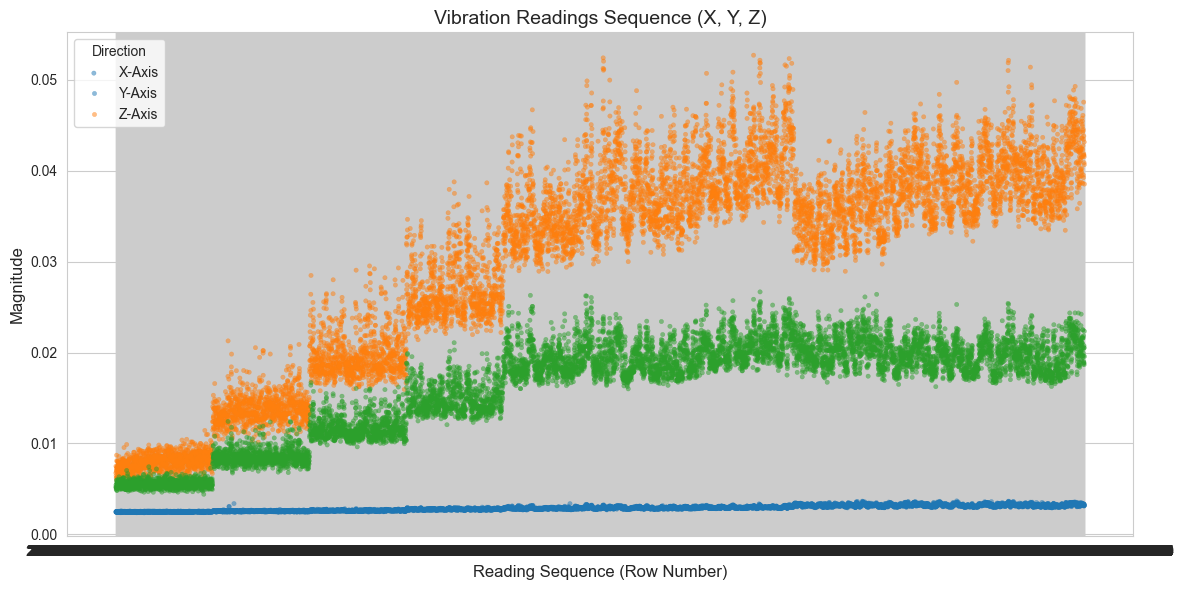

In [7]:
# 1. Preparar los datos (Reset index para que "index" sea una columna usable)
df_reset = data_df.reset_index() 

df_long = df_reset.melt(
    id_vars="timestamp", # Ahora "index" es una columna real
    value_vars=["vibration_x", "vibration_y", "vibration_z"],
    var_name="Axis", 
    value_name="Reading"
)

# 2. Configuración del estilo
sns.set_style("whitegrid")

# 3. Crear la figura y el objeto "ax"
fig, ax = plt.subplots(figsize=(12, 6))

# 4. Graficar (Usamos la columna "index" que creamos en el melt)
sns.scatterplot(
    data=df_long, 
    x="timestamp", 
    y="Reading", 
    hue="Axis", 
    alpha=0.5,
    s=10,
    edgecolor=None,
    ax=ax 
)

# 5. Formateo
ax.set_title("Vibration Readings Sequence (X, Y, Z)", fontsize=14)
ax.set_xlabel("Reading Sequence (Row Number)", fontsize=12)
ax.set_ylabel("Magnitude", fontsize=12)
ax.legend(title="Direction", labels=["X-Axis", "Y-Axis", "Z-Axis"])

fig.tight_layout()
plt.show()

## Generating the knowledge database

In [8]:
motor_specs = {
    "class": ["Velocidad 2", "Velocidad 4", "Velocidad 6", "Velocidad 8", "Velocidad 10",
              "Velocidad 11", "Velocidad 12", "Velocidad 13", "Velocidad 14", "Velocidad 15"],
    "theoretical_rpm": [476, 837, 1198, 1558, 1979, 2155, 2399, 2699, 2939, 2999],
    "freq_hz": [8, 14, 20, 26, 33, 36, 40, 45, 49, 50]
}

knowledge_df = pd.DataFrame(motor_specs)
knowledge_df

,class,theoretical_rpm,freq_hz
0,Velocidad 2,476,8
1,Velocidad 4,837,14
2,Velocidad 6,1198,20
3,Velocidad 8,1558,26
4,Velocidad 10,1979,33
5,Velocidad 11,2155,36
6,Velocidad 12,2399,40
7,Velocidad 13,2699,45
8,Velocidad 14,2939,49
9,Velocidad 15,2999,50


In [9]:
class MotorKnowledgeBase:
    """
    "Knowledge" component of the MAPE-K cycle for the Baldor-Reliance motor.
    Maintains the physical model and coordinate transformations.
    """
    def __init__(self, rpm_map):
        # Mapping of speed levels to actual RPM
        self.rpm_map = rpm_map
        self.k_centrifugal = 0    # Slope of vibration vs omega^2
        self.bias_static = 0      # Residual or background vibration
        self.theta_iatrogenic = 0 # Sensor tilt angle
        self.is_calibrated = False

    def rpm_to_rads(self, rpm):
        """Converts RPM to Radians per second."""
        return (rpm * 2 * np.pi) / 60

    def fit_physics_model(self, df):
        """
        Calibrates the model A = k * omega^2 + b using historical data.
        This defines what a "Healthy Motor" looks like.
        """
        df["rpm"] = df["level"].map(self.rpm_map)
        df["omega_sq"] = self.rpm_to_rads(df["rpm"])**2
        
        # Total vibration magnitude (Vector Sum)
        df["v_total"] = np.sqrt(df["vibration_x"]**2 + df["vibration_y"]**2 + df["vibration_z"]**2)
        
        # Aggregate by level to remove noise
        summary = df.groupby("level").agg({"v_total": "mean", "omega_sq": "first"}).reset_index()
        
        # Linear Regression to obtain the physical constant "k"
        model = LinearRegression().fit(summary[["omega_sq"]], summary["v_total"])
        self.k_centrifugal = model.coef_[0]
        self.bias_static = model.intercept_
        self.is_calibrated = True
        return self.k_centrifugal, self.bias_static

    def get_rotation_matrix(self, theta_deg):
        """Generates the rotation matrix R (Rotation on Y-axis)."""
        theta = np.radians(theta_deg)
        return np.array([
            [np.cos(theta),  0, np.sin(theta)],
            [0,              1, 0],
            [-np.sin(theta), 0, np.cos(theta)]
        ])

    def estimate_iatrogenesis_angle(self, df):
        """
        Calculates the tilt angle based on the vibration distribution 
        between the X and Z axes (Iatrogenesis).
        """
        avg_x = df["vibration_x"].mean()
        avg_z = df["vibration_z"].mean()
        
        # The angle is estimated by the trigonometric relationship of the readings
        self.theta_iatrogenic = np.degrees(np.arctan2(avg_x, avg_z))
        return self.theta_iatrogenic

    def analyze_symmetry(self, df):
        """
        Symmetry Analysis Algorithm.
        If the X/Z ratio is constant across all speeds, it is IATROGENESIS.
        """
        ratios = []
        for level in sorted(df["level"].unique()):
            subset = df[df["level"] == level]
            # Calculate the ratio between X and Z axes
            ratio = subset["vibration_x"].mean() / (subset["vibration_z"].mean() + 1e-9)
            ratios.append(ratio)
        
        # A low standard deviation in ratios indicates a static error (misaligned sensor)
        ratio_stability = np.std(ratios)
        is_iatrogenic = ratio_stability < 0.1  # Stability threshold
        return is_iatrogenic, ratio_stability

In [10]:
rpm_dict = dict(zip(knowledge_df["class"], knowledge_df["theoretical_rpm"]))
kb = MotorKnowledgeBase(rpm_map=rpm_dict)

In [11]:
is_iatrogenic, stability_score = kb.analyze_symmetry(data_df)

In [12]:
if is_iatrogenic:
    # If it's iatrogenesis, calculate the tilt angle
    angle = kb.estimate_iatrogenesis_angle(data_df)
    print(f"⚠️ Iatrogenesis Detected!")
    print(f"The sensor is tilted by approximately {angle:.2f} degrees.")
    print(f"Stability Score (Std Dev of ratios): {stability_score:.4f}")
else:
    print("✅ No Iatrogenesis detected. Vibration patterns vary across speeds.")

⚠️ Iatrogenesis Detected!
The sensor is tilted by approximately 10.23 degrees.
Stability Score (Std Dev of ratios): 0.0916
